# 💼 Salary Prediction using Machine Learning

## 📌 Project Overview
This project aims to predict employee salaries based on:
- Years of Experience
- Skill Level

The goal is to:
- Analyze relationships between features
- Build a predictive model
- Evaluate performance
- Perform statistical validation



## 🎯 Business Problem

Organizations need a reliable method to estimate salaries based on candidate profiles.

This project helps to:
- Understand salary drivers
- Build a predictive salary model


### ✅ 2) Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### ✅ 3) Data generation

In [3]:
np.random.seed(42)
n = 250

experience = np.random.uniform(0, 15, n)
skill = np.random.uniform(1, 10, n)
noise = np.random.normal(0, 7000, n)

salary = 25000 + 8000 * experience + 3000 * skill + noise

df = pd.DataFrame({
    'experience': experience,
    'skill': skill,
    'salary': salary
})

df.head()

,experience,skill,salary
0,5.618102,3.650040,83287.226178
1,14.260715,4.465880,165616.551316
2,10.979909,8.660230,145472.930016
3,8.979877,3.852298,104357.586653
4,2.340280,2.525435,45009.638314


### ✅ 4) Data Exploration (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   experience  250 non-null    float64
 1   skill       250 non-null    float64
 2   salary      250 non-null    float64
dtypes: float64(3)
memory usage: 6.0 KB


In [5]:
df.describe()

,experience,skill,salary
count,250.000000,250.000000,250.000000
mean,7.356228,5.560374,100350.821933
std,4.461606,2.702755,37953.500320
min,0.075924,1.097539,27955.248020
25%,3.463663,3.502174,65590.379549
50%,7.539871,5.728595,99910.589361
75%,11.299293,7.813183,130561.508419
max,14.803304,9.936683,180597.742831


### ✅ 5) Visualization (Visual Analysis)

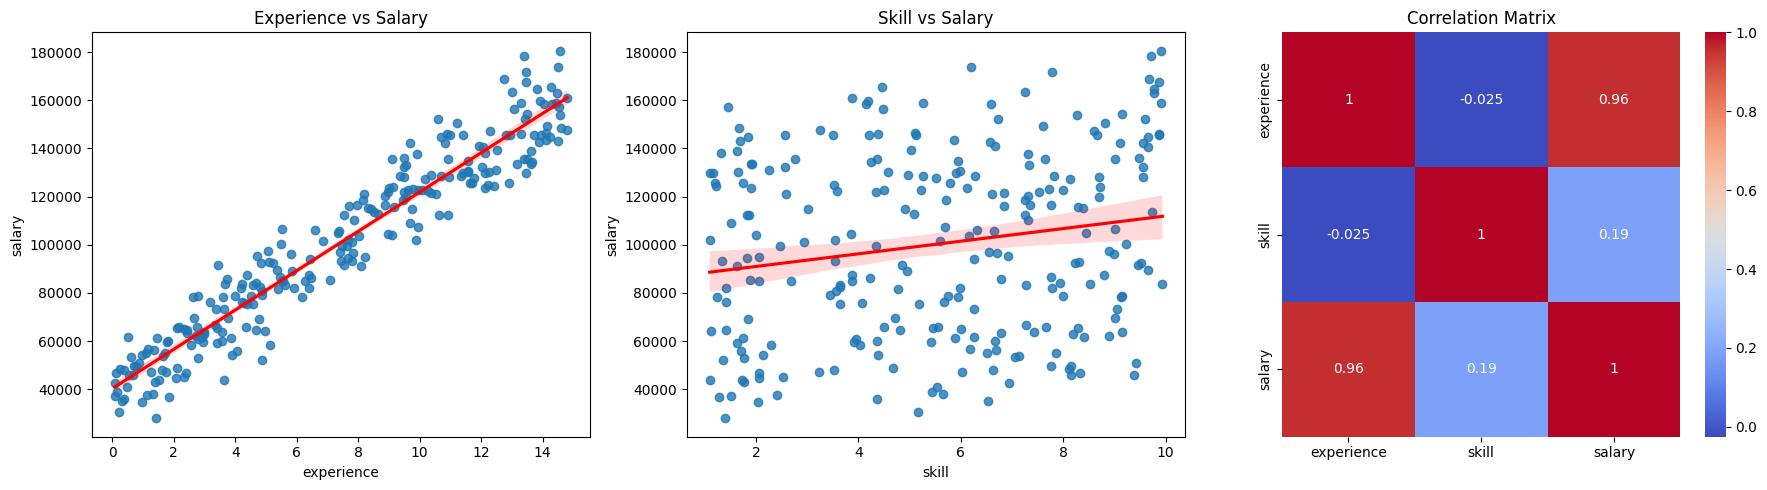

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.regplot(x=df['experience'], y=df['salary'], ax=axes[0], line_kws={'color':'red'})
axes[0].set_title("Experience vs Salary")

sns.regplot(x=df['skill'], y=df['salary'], ax=axes[1], line_kws={'color':'red'})
axes[1].set_title("Skill vs Salary")

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

### 🧠 Analysis

## 🔍 Insights from Visualization

- ✅ Strong positive relationship between **experience and salary**
- ✅ Moderate relationship between **skill and salary**
- ✅ Experience is the most important feature

Conclusion:
> Experience plays a dominant role in salary prediction.

### ✅ 6) Data preparation

In [8]:
X = df[['experience', 'skill']]
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### ✅ 7) Model building

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [8197.90671413 2784.02292025]
Intercept: 24680.88873465004


### 🧠 Interpretation

#### 📊 Model Interpretation

- Experience coefficient ≈ 8000  
- Skill coefficient ≈ 3000  

✅ This confirms:
- Experience has stronger impact on salary

### ✅ 8) Predicting and Evaluation

In [10]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.9623363756457589
MAE: 5830.968668168143
RMSE: 7239.508207320694


#### 📈 Model Performance

- ✅ R² ≈ 0.96 → Excellent performance
- ✅ MAE ≈ 5,000 → Low prediction error
- ✅ RMSE slightly higher → normal

Conclusion:
> The model is highly accurate and reliable.


### ✅ 9) Residuals Analysis

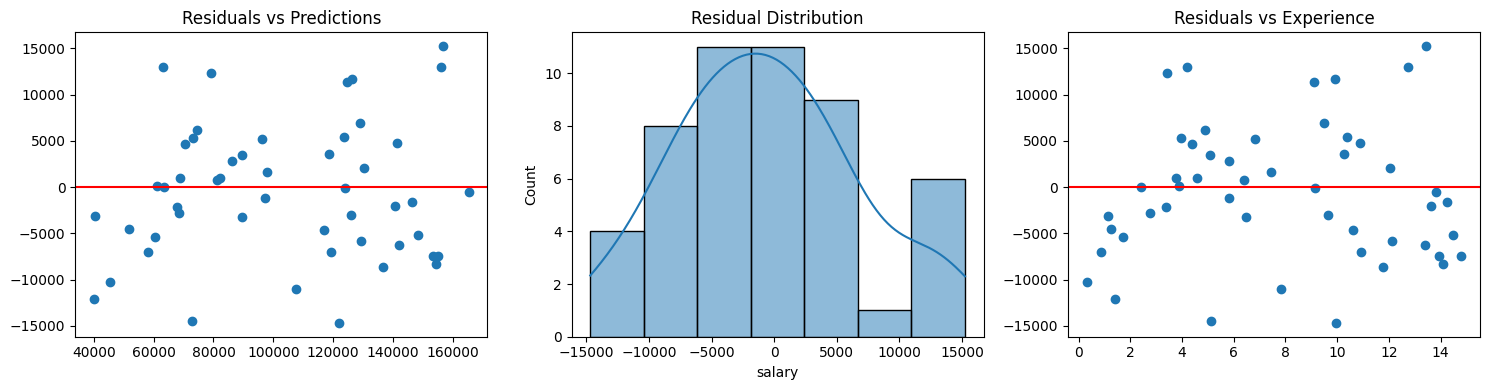

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(15,4))

# Residuals vs Prediction
plt.subplot(1,3,1)
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions")

# Distribution
plt.subplot(1,3,2)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

# Residuals vs Experience
plt.subplot(1,3,3)
plt.scatter(X_test['experience'], residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Experience")

plt.tight_layout()
plt.show()

#### 📉 Residual Analysis

- ✅ Residuals are randomly distributed
- ✅ No visible pattern
- ✅ Errors follow normal distribution

Conclusion:
> Linear Regression assumptions are satisfied.
``

## 🏁 Final Conclusion

- ✅ Experience is the strongest predictor
- ✅ Skill has a moderate impact
- ✅ The model shows high accuracy (R² ≈ 0.96)
- ✅ Residual analysis confirms model validity

---

## 🚀 Future Improvements

- Try Random Forest or XGBoost
- Add more features (education, job role)
- Deploy model to production